In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **1. Import Library**

In [ ]:
#Type your code here
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

# **2. Exploratory Data Analysis (EDA)**

In [ ]:
# Load Data
file_path = '/content/drive/MyDrive/DATA_KORBAN.xlsx'
data = pd.read_excel(file_path)
# Menampilkan 5 data teratas
data.head()

,ID_KORBAN_KECELAKAAN,NAMA,UMUR,KELOMPOK_UMUR,JENIS_KELAMIN,PROFESI,CIDERA,ID_KECELAKAAN,NAMA_KANTOR,KASUS_KECELAKAAN,SIFAT_KECELAKAAN,TGL_KEJADIAN,NAMA_KABKOTA,NAMA_CAMAT,KENDARAAN_KORBAN
0,0504039.0504004.2101050537.01.MDBDQ,KANTOR WILAYAH JAWA TIMUR,25.0,6 SD 25,PRIA,KARYAWAN SWASTA,LL,0504039.0504004.2101050537.01,LOKET KANTOR CABANG MADIUN,TABRAKAN DEPAN-SAMPING,NORMAL,01/01/2021 00:10,KAB. NGAWI,KARANGJATI,MOTOR
1,0500025.0513001.2101040834.01.IIWZS,KANTOR WILAYAH JAWA TIMUR,16.0,6 SD 25,PRIA,PELAJAR MAHASISWA,LL,0500025.0513001.2101040834.01,LOKET KANTOR PELAYANAN SIDOARJO,TABRAKAN DEPAN-SAMPING,NORMAL,01/01/2021 00:30,KAB. SIDOARJO,KRIAN,MOTOR
2,0503002.0503002.2101201034.01.6GVLI,KANTOR WILAYAH JAWA TIMUR,55.0,25 SD 55,PRIA,BURUH PETANI,LL,0503002.0503002.2101201034.01,LOKET KANTOR CABANG KEDIRI,TABRAKAN DEPAN-DEPAN,NORMAL,01/01/2021 01:00,KAB. KEDIRI,BANYAKAN,MOTOR
3,0500825.0509002.2101031027.01.5QN3A,KANTOR WILAYAH JAWA TIMUR,19.0,6 SD 25,PRIA,PELAJAR MAHASISWA,LL,0500825.0509002.2101031027.01,LOKET KANTOR PELAYANAN MOJOKERTO,TABRAKAN DEPAN-DEPAN,NORMAL,01/01/2021 02:00,KAB. MOJOKERTO,GEDEG,MOTOR
4,0500825.0509002.2101031027.01.R4DAN,KANTOR WILAYAH JAWA TIMUR,19.0,6 SD 25,PRIA,PELAJAR MAHASISWA,LL,0500825.0509002.2101031027.01,LOKET KANTOR PELAYANAN MOJOKERTO,TABRAKAN DEPAN-DEPAN,NORMAL,01/01/2021 02:00,KAB. MOJOKERTO,GEDEG,MOTOR


In [ ]:
# Melihat dimensi dataframe
print(data.shape)

(195351, 15)


In [ ]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195351 entries, 0 to 195350
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID_KORBAN_KECELAKAAN  195351 non-null  object 
 1   NAMA                  195351 non-null  object 
 2   UMUR                  195012 non-null  float64
 3   KELOMPOK_UMUR         195351 non-null  object 
 4   JENIS_KELAMIN         195351 non-null  object 
 5   PROFESI               195351 non-null  object 
 6   CIDERA                195351 non-null  object 
 7   ID_KECELAKAAN         195351 non-null  object 
 8   NAMA_KANTOR           195351 non-null  object 
 9   KASUS_KECELAKAAN      195351 non-null  object 
 10  SIFAT_KECELAKAAN      195351 non-null  object 
 11  TGL_KEJADIAN          195351 non-null  object 
 12  NAMA_KABKOTA          195351 non-null  object 
 13  NAMA_CAMAT            195351 non-null  object 
 14  KENDARAAN_KORBAN      195351 non-null  object 
dtype

In [ ]:
data.value_counts()

,,,,,,,,,,,,,,,count
ID_KORBAN_KECELAKAAN,NAMA,UMUR,KELOMPOK_UMUR,JENIS_KELAMIN,PROFESI,CIDERA,ID_KECELAKAAN,NAMA_KANTOR,KASUS_KECELAKAAN,SIFAT_KECELAKAAN,TGL_KEJADIAN,NAMA_KABKOTA,NAMA_CAMAT,KENDARAAN_KORBAN,
FFFF95EE-8729-230C-16D1-B7EB4C6F4A38,KANTOR WILAYAH JAWA TIMUR,23.0,6 SD 25,PRIA,KARYAWAN SWASTA,MD,C.2EB1156C-6A60-46FF-AF63-15A227F7D,LOKET KANTOR PELAYANAN TUBAN,TABRAKAN DEPAN-BELAKANG,NORMAL,02/11/2023 02:30,KAB. LAMONGAN,SUKODADI,MOTOR,1
00004228-7DB6-C491-84C6-B11471CCF9DD,KANTOR WILAYAH JAWA TIMUR,16.0,6 SD 25,PRIA,PELAJAR MAHASISWA,LL,C.725345AF-63F0-4C9F-8923-28BAD3E7A,LOKET KANTOR CABANG MALANG,TABRAKAN DEPAN-DEPAN,NORMAL,21/06/2024 08:45,KOTA BATU,JUNREJO,MOTOR,1
0000CF48-4078-019F-D348-82089057EABC,KANTOR WILAYAH JAWA TIMUR,62.0,DI ATAS 56,PRIA,WIRASWASTA,LL,C.1C2CD61C-CECE-D7DA-67D2-FE2144734,LOKET KANTOR PELAYANAN BANYUWANGI,KECELAKAAN TUNGGAL/SLIP SENDIRI,NORMAL,15/12/2023 16:30,KAB. BANYUWANGI,PURWOHARJO,MOTOR,1
0000D483-DE19-F0DF-9BF8-1A686B356A8B,KANTOR WILAYAH JAWA TIMUR,53.0,25 SD 55,WANITA,LAIN LAIN,MD,C.4A69723D-7B5B-3EC0-9910-FE3B62694,LOKET KANTOR PELAYANAN BANYUWANGI,TABRAKAN DEPAN-SAMPING,NORMAL,06/01/2024 04:00,KAB. BANYUWANGI,WONGSOREJO,MOTOR,1
FFF65D1B-C218-299B-9EE5-AB6CC61F39A4,KANTOR WILAYAH JAWA TIMUR,44.0,25 SD 55,WANITA,KARYAWAN SWASTA,LL,C.0DD28625-E7D6-45E0-8865-978E4E018,LOKET KANTOR CABANG SURABAYA,TABRAKAN DEPAN-BELAKANG,NORMAL,27/11/2024 17:10,KOTA SURABAYA,WONOKROMO,MOTOR,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
00064160-7EA1-64FF-A36B-611868895B35,KANTOR WILAYAH JAWA TIMUR,41.0,25 SD 55,PRIA,WIRASWASTA,LL,C.02FDB39D-B3C9-40C4-B26E-E0EB8D905,LOKET KANTOR PELAYANAN TULUNGAGUNG,TABRAKAN DEPAN-SAMPING,NORMAL,17/03/2024 03:00,KAB. TULUNGAGUNG,BOYOLANGU,MOTOR,1
0005B5A2-6E80-EC94-7F57-DA91F83047F2,KANTOR WILAYAH JAWA TIMUR,60.0,DI ATAS 56,WANITA,KARYAWAN SWASTA,LL,C.98F5DEC6-83A5-44D4-9DFB-77A87CAD7,LOKET KANTOR PELAYANAN TUBAN,MENABRAK PEJALAN KAKI/SEJENISNYA,NORMAL,19/11/2023 08:30,KAB. LAMONGAN,PACIRAN,PEJALAN KAKI,1
000523C2-3DF4-8375-56AF-43AC302A7A80,KANTOR WILAYAH JAWA TIMUR,47.0,25 SD 55,WANITA,WIRASWASTA,LL,C.4BD140E2-B36E-4424-B1BC-00A922906,LOKET KANTOR CABANG JEMBER,TABRAKAN DEPAN-SAMPING,NORMAL,10/12/2024 07:05,KAB. JEMBER,KALIWATES,KEND PRIBADI,1


In [ ]:
# Menampilkan Statistik Deskriptif (Numerik)
data.describe()

,UMUR
count,195012.000000
mean,35.527726
std,18.839395
min,0.000000
25%,19.000000
50%,32.000000
75%,51.000000
max,100.000000


In [ ]:
# Menampilkan Statistik Deskriptif (Kategorikal)
data.describe(include=['object']).T

,count,unique,top,freq
ID_KORBAN_KECELAKAAN,195351,195351,E636517D-0B8F-777B-F87C-6002EB236B3B,1
NAMA,195351,1,KANTOR WILAYAH JAWA TIMUR,195351
KELOMPOK_UMUR,195351,4,25 SD 55,79076
JENIS_KELAMIN,195351,3,PRIA,132136
PROFESI,195351,7,WIRASWASTA,72245
CIDERA,195351,2,LL,179860
ID_KECELAKAAN,195351,125961,0504029.0504005.2212040247.01,56
NAMA_KANTOR,195351,14,LOKET KANTOR CABANG MADIUN,27754
KASUS_KECELAKAAN,195351,23,TABRAKAN DEPAN-DEPAN,60759
SIFAT_KECELAKAAN,195351,2,NORMAL,186439


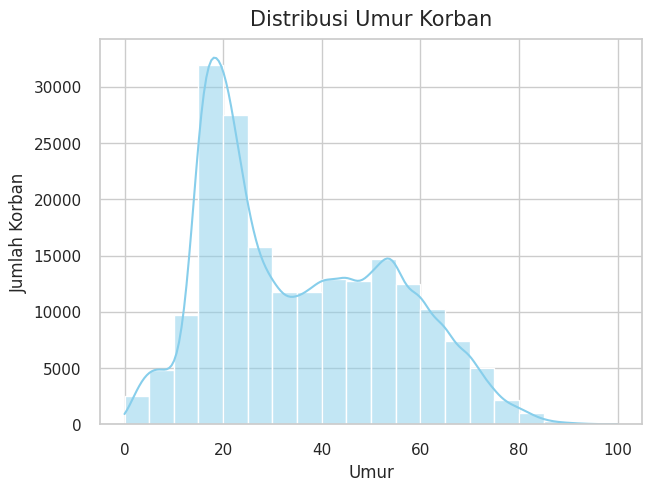

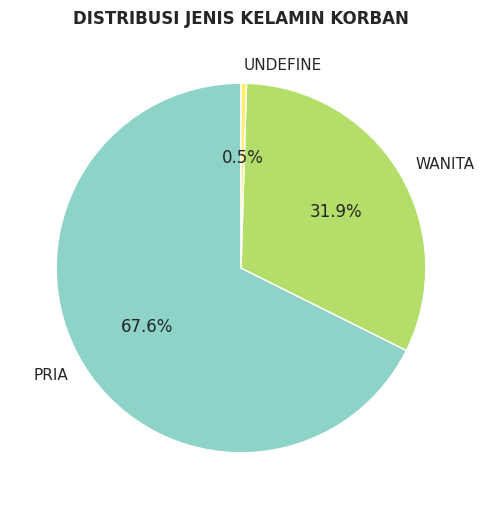

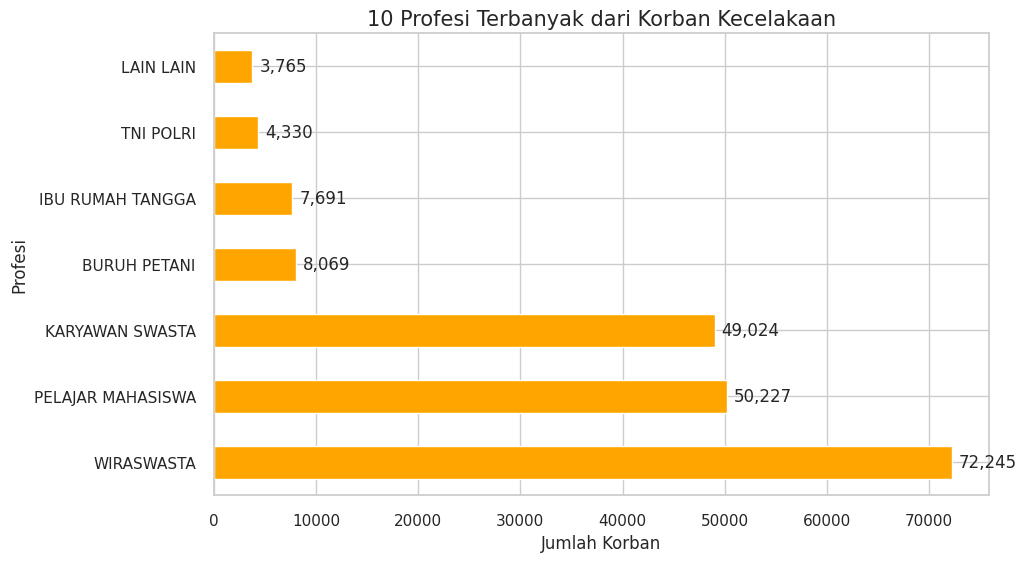

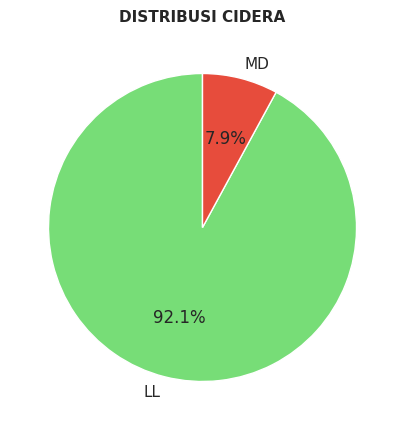

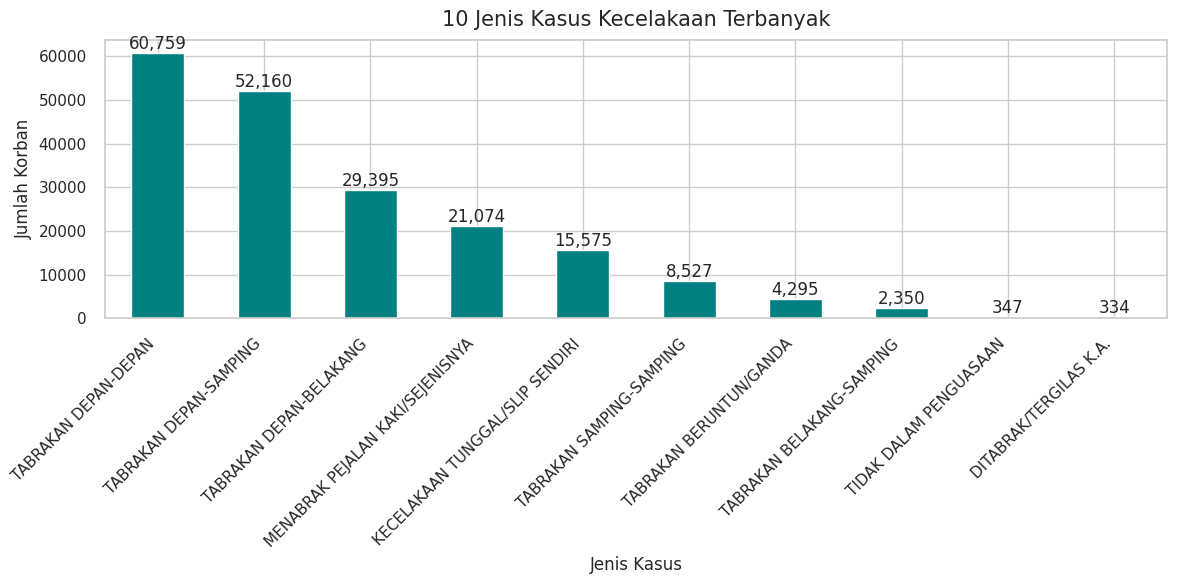

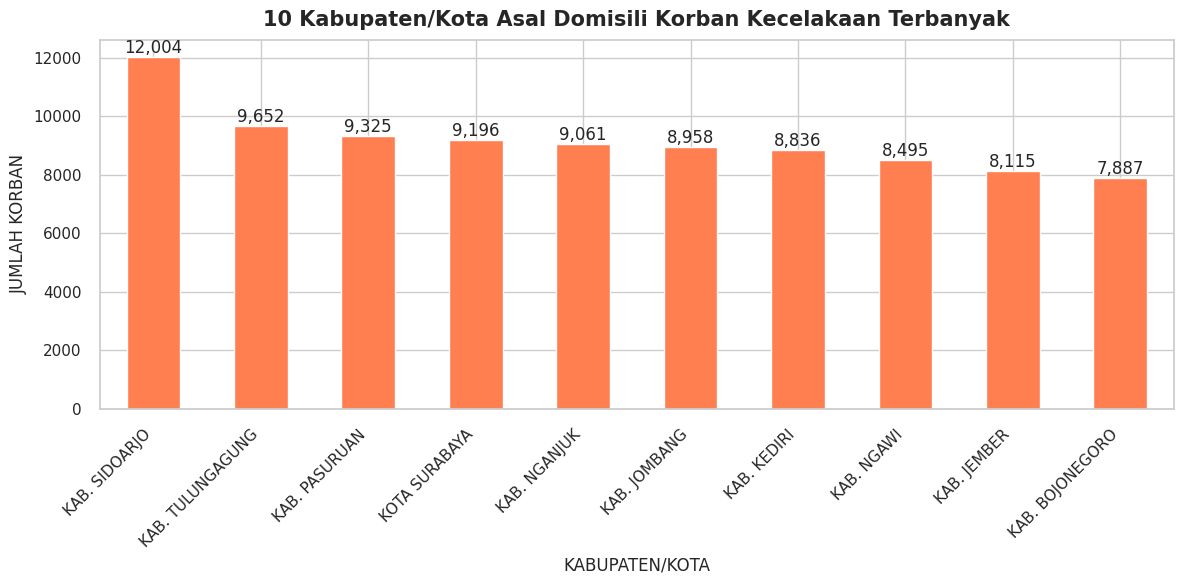

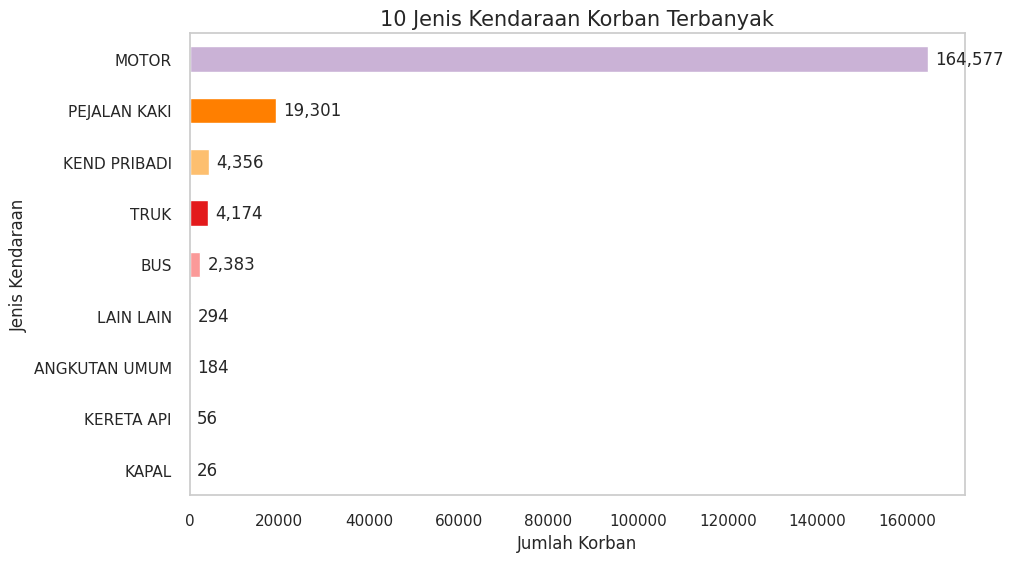

In [ ]:
# Visualisasi Dataset
sns.set(style="whitegrid")

# 1. Distribusi umur (histogram)
plt.figure(figsize=(7,5))
sns.histplot(data['UMUR'], bins=20, kde=True, color="skyblue")
plt.title("Distribusi Umur Korban",  fontsize=15, pad=10)
plt.xlabel("Umur")
plt.ylabel("Jumlah Korban")
plt.show()

# 2. Pie chart jenis kelamin
plt.figure(figsize=(6,6))
data['JENIS_KELAMIN'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap="Set3")
plt.title("DISTRIBUSI JENIS KELAMIN KORBAN", fontsize=12, pad=10,weight='bold')
plt.ylabel("")
plt.show()

# 3. Bar chart profesi
plt.figure(figsize=(10,6))
ax = data['PROFESI'].value_counts().head(10).plot(kind='barh', color="orange")
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5)
plt.title("10 Profesi Terbanyak dari Korban Kecelakaan",  fontsize=15)
plt.xlabel("Jumlah Korban")
plt.ylabel("Profesi")
plt.show()

# Bar chart kasus kecelakaan
sns.set(style="whitegrid")
plt.figure(figsize=(5,5))

data['CIDERA'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=["#77dd77", "#e74c3c"])

plt.title("DISTRIBUSI CIDERA", fontsize=11, pad=10, weight='bold')
plt.ylabel("")
plt.show()

# 5. Bar chart kasus kecelakaan
plt.figure(figsize=(12,6))
ax = data['KASUS_KECELAKAAN'].value_counts().head(10).plot(kind='bar', color="teal")
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.title("10 Jenis Kasus Kecelakaan Terbanyak", fontsize=15, pad=10)
plt.xlabel("Jenis Kasus")
plt.ylabel("Jumlah Korban")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 6. Top 10 Kabupaten/Kota
plt.figure(figsize=(12,6))
ax = data['NAMA_KABKOTA'].value_counts().head(10).plot(kind='bar', color="coral")
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.title("10 Kabupaten/Kota Asal Domisili Korban Kecelakaan Terbanyak", fontsize=15, pad=10, weight='bold')
plt.xlabel("KABUPATEN/KOTA")
plt.ylabel("JUMLAH KORBAN")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 7. Jenis Kendaraan Korban
plot_data = data['KENDARAAN_KORBAN'].value_counts().head(10)
plt.figure(figsize=(10,6))
colors = sns.color_palette('Paired', n_colors=10)
ax = plot_data.iloc[::-1].plot(kind='barh', color=colors)
ax.grid(False)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5)
plt.title("10 Jenis Kendaraan Korban Terbanyak", fontsize=15)
plt.xlabel("Jumlah Korban")
plt.ylabel("Jenis Kendaraan")
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.

In [ ]:
# Melakukan drop pada kolom yang tidak berhubungan langsung dengan analisis
data = data.drop(columns=['ID_KORBAN_KECELAKAAN', 'NAMA', 'KELOMPOK_UMUR', 'ID_KECELAKAAN', 'NAMA_CAMAT', 'NAMA_KANTOR'])
data = data[data['JENIS_KELAMIN'] != 'UNDEFINE']
print(f"Dimensi data setelah pembersihan: {data.shape}")

Dimensi data setelah pembersihan: (194423, 9)


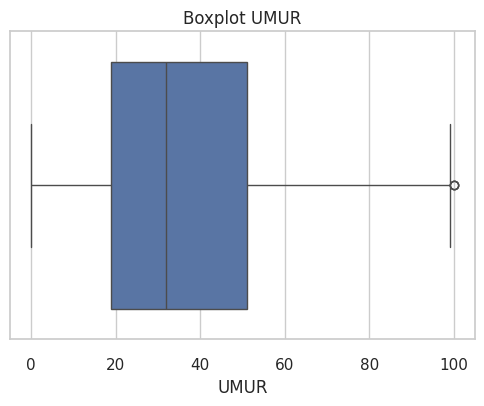

In [ ]:
# Visualisasi Boxplot (Sebelum Scaling)
num_cols_raw = data.select_dtypes(include=['float64', 'int32', 'int64']).columns.tolist()

for col in num_cols_raw:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot {col}")
    plt.show()

In [ ]:
# Mengecek apakah ada data null
print(data.isnull().sum().sum())
# Mengecek dataset menggunakan duplicated().sum()
print(data.duplicated().sum())

260
3039


In [ ]:
# Hitung median umur
median_umur = data['UMUR'].median()

# Isi NaN dengan median
data['UMUR'] = data['UMUR'].fillna(median_umur)

# Cek hasil
print("Median UMUR:", median_umur)
print("Sisa missing value di UMUR:", data['UMUR'].isnull().sum())

Median UMUR: 32.0
Sisa missing value di UMUR: 0


In [ ]:
# Ubah ke format datetime
data['TGL_KEJADIAN'] = pd.to_datetime(data['TGL_KEJADIAN'], format='mixed', errors='coerce')

# Ambil jam, hari, bulan
data['JAM'] = data['TGL_KEJADIAN'].dt.hour
data['HARI'] = data['TGL_KEJADIAN'].dt.isocalendar().day.apply(lambda x: 1 if x in [6, 7] else 0).astype(int) # 1 = Weekend dan 0 = Weekday.
data['BULAN'] = data['TGL_KEJADIAN'].dt.month

# Transformasi siklikal untuk jam
data['JAM_sin'] = np.sin(2 * np.pi * data['JAM'] / 24)
data['JAM_cos'] = np.cos(2 * np.pi * data['JAM'] / 24)

# Transformasi siklikal untuk bulan
data['BULAN_sin'] = np.sin(2 * np.pi * data['BULAN'] / 12)
data['BULAN_cos'] = np.cos(2 * np.pi * data['BULAN'] / 12)

In [ ]:
data[['JAM', 'BULAN', 'JAM_sin', 'JAM_cos', 'BULAN_sin', 'BULAN_cos']].head(10)

,JAM,BULAN,JAM_sin,JAM_cos,BULAN_sin,BULAN_cos
0,0,1,0.000000,1.000000,0.5,0.866025
1,0,1,0.000000,1.000000,0.5,0.866025
2,1,1,0.258819,0.965926,0.5,0.866025
3,2,1,0.500000,0.866025,0.5,0.866025
4,2,1,0.500000,0.866025,0.5,0.866025
5,2,1,0.500000,0.866025,0.5,0.866025
6,3,1,0.707107,0.707107,0.5,0.866025
7,3,1,0.707107,0.707107,0.5,0.866025
8,3,1,0.707107,0.707107,0.5,0.866025
9,3,1,0.707107,0.707107,0.5,0.866025


In [ ]:
data[['TGL_KEJADIAN', 'JAM', 'HARI', 'BULAN', 'JAM_sin', 'JAM_cos', 'BULAN_sin', 'BULAN_cos']].head(10)

,TGL_KEJADIAN,JAM,HARI,BULAN,JAM_sin,JAM_cos,BULAN_sin,BULAN_cos
0,2021-01-01 00:10:00,0,0,1,0.000000,1.000000,0.5,0.866025
1,2021-01-01 00:30:00,0,0,1,0.000000,1.000000,0.5,0.866025
2,2021-01-01 01:00:00,1,0,1,0.258819,0.965926,0.5,0.866025
3,2021-01-01 02:00:00,2,0,1,0.500000,0.866025,0.5,0.866025
4,2021-01-01 02:00:00,2,0,1,0.500000,0.866025,0.5,0.866025
5,2021-01-01 02:00:00,2,0,1,0.500000,0.866025,0.5,0.866025
6,2021-01-01 03:00:00,3,0,1,0.707107,0.707107,0.5,0.866025
7,2021-01-01 03:00:00,3,0,1,0.707107,0.707107,0.5,0.866025
8,2021-01-01 03:30:00,3,0,1,0.707107,0.707107,0.5,0.866025
9,2021-01-01 03:30:00,3,0,1,0.707107,0.707107,0.5,0.866025


In [ ]:
numerik_cols = data.select_dtypes(include=['float64', 'int32', 'int64']).columns.tolist()
# Hapus kolom JAM, BULAN dari daftar
numerik_cols = [col for col in numerik_cols if col not in ['JAM', 'BULAN']]

print(numerik_cols)

['UMUR', 'HARI', 'JAM_sin', 'JAM_cos', 'BULAN_sin', 'BULAN_cos']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194423 entries, 0 to 195350
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   UMUR              194423 non-null  float64       
 1   JENIS_KELAMIN     194423 non-null  object        
 2   PROFESI           194423 non-null  object        
 3   CIDERA            194423 non-null  object        
 4   KASUS_KECELAKAAN  194423 non-null  object        
 5   SIFAT_KECELAKAAN  194423 non-null  object        
 6   TGL_KEJADIAN      194423 non-null  datetime64[ns]
 7   NAMA_KABKOTA      194423 non-null  object        
 8   KENDARAAN_KORBAN  194423 non-null  object        
 9   JAM               194423 non-null  int32         
 10  HARI              194423 non-null  int64         
 11  BULAN             194423 non-null  int32         
 12  JAM_sin           194423 non-null  float64       
 13  JAM_cos           194423 non-null  float64       
 14  BULAN_sin

In [ ]:
# Melakukan feature scaling menggunakan MinMaxScaler() untuk fitur numerik
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[numerik_cols])
scaled_data = pd.DataFrame(scaled_data, columns=numerik_cols).reset_index(drop=True)

In [ ]:
scaled_data

,UMUR,HARI,JAM_sin,JAM_cos,BULAN_sin,BULAN_cos
0,0.25,0.0,0.50000,1.000000,0.75,0.933013
1,0.16,0.0,0.50000,1.000000,0.75,0.933013
2,0.55,0.0,0.62941,0.982963,0.75,0.933013
3,0.19,0.0,0.75000,0.933013,0.75,0.933013
4,0.19,0.0,0.75000,0.933013,0.75,0.933013
...,...,...,...,...,...,...
194418,0.61,0.0,0.37059,0.982963,0.25,0.066987
194419,0.24,0.0,0.37059,0.982963,0.25,0.066987
194420,0.19,0.0,0.37059,0.982963,0.25,0.066987
194421,0.32,0.0,0.37059,0.982963,0.25,0.066987


In [ ]:
def merge_minoritas(df, col_name, threshold=0.02):
    """
    Menggabungkan kategori dengan proporsi < threshold menjadi 'MINORITAS'
    df        : DataFrame
    col_name  : nama kolom kategori
    threshold : proporsi minimal (default 0.02 = 2%)
    """
    # Hitung proporsi tiap kategori
    proporsi = df[col_name].value_counts(normalize=True)

    # Kategori yang jumlahnya kecil
    kategori_kecil = proporsi[proporsi < threshold].index

    # Ganti kategori kecil menjadi 'MINORITAS'
    df[col_name] = df[col_name].replace(kategori_kecil, 'MINORITAS')

    return df

data = merge_minoritas(data, 'PROFESI', threshold=0.02)
data = merge_minoritas(data, 'KENDARAAN_KORBAN', threshold=0.02)
data = merge_minoritas(data, 'KASUS_KECELAKAAN', threshold=0.02)

# Cek hasilnya
data['PROFESI'].value_counts(normalize=True) * 100

,proportion
PROFESI,
WIRASWASTA,36.986879
PELAJAR MAHASISWA,25.725351
KARYAWAN SWASTA,25.123056
BURUH PETANI,4.134799
IBU RUMAH TANGGA,3.918775
TNI POLRI,2.219388
MINORITAS,1.891751


In [ ]:
data['KENDARAAN_KORBAN'].value_counts(normalize=True) * 100

,proportion
KENDARAAN_KORBAN,
MOTOR,84.258550
PEJALAN KAKI,9.865088
KEND PRIBADI,2.227103
TRUK,2.143265
MINORITAS,1.505995


In [ ]:
data['KASUS_KECELAKAAN'].value_counts(normalize=True) * 100

,proportion
KASUS_KECELAKAAN,
TABRAKAN DEPAN-DEPAN,31.049824
TABRAKAN DEPAN-SAMPING,26.742721
TABRAKAN DEPAN-BELAKANG,15.072291
MENABRAK PEJALAN KAKI/SEJENISNYA,10.776503
KECELAKAAN TUNGGAL/SLIP SENDIRI,7.957392
TABRAKAN SAMPING-SAMPING,4.370882
TABRAKAN BERUNTUN/GANDA,2.202414
MINORITAS,1.827973


In [ ]:
# Ambil kolom kategorikal
kategorikal_cols = data.select_dtypes(include=['object']).columns.tolist()
kategorikal_cols = [col for col in kategorikal_cols if col not in ['CIDERA', 'NAMA_KABKOTA']]

In [ ]:
# One Hot Encoding
encoded_data = pd.get_dummies(data[kategorikal_cols], dtype=int).reset_index(drop=True)
encoded_data.T

,0,1,2,3,4,5,6,7,8,9,...,194413,194414,194415,194416,194417,194418,194419,194420,194421,194422
JENIS_KELAMIN_PRIA,1,1,1,1,1,1,1,1,1,0,...,1,1,1,0,1,1,1,0,1,0
JENIS_KELAMIN_WANITA,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,1,0,1
PROFESI_BURUH PETANI,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PROFESI_IBU RUMAH TANGGA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
PROFESI_KARYAWAN SWASTA,1,0,0,0,0,0,0,1,0,1,...,0,1,1,0,0,1,1,1,1,1
PROFESI_MINORITAS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PROFESI_PELAJAR MAHASISWA,0,1,0,1,1,1,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
PROFESI_TNI POLRI,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
PROFESI_WIRASWASTA,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
KASUS_KECELAKAAN_KECELAKAAN TUNGGAL/SLIP SENDIRI,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
final_data = pd.concat([scaled_data, encoded_data], axis=1)

In [ ]:
# Tampilkan semua kolom
final_data.T

,0,1,2,3,4,5,6,7,8,9,...,194413,194414,194415,194416,194417,194418,194419,194420,194421,194422
UMUR,0.250000,0.160000,0.550000,0.190000,0.190000,0.170000,0.220000,0.210000,0.360000,0.260000,...,0.150000,0.270000,0.300000,0.420000,0.640000,0.610000,0.240000,0.190000,0.320000,0.220000
HARI,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
JAM_sin,0.500000,0.500000,0.629410,0.750000,0.750000,0.750000,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.146447,0.146447,0.146447,0.250000,0.370590,0.370590,0.370590,0.370590,0.370590
JAM_cos,1.000000,1.000000,0.982963,0.933013,0.933013,0.933013,0.853553,0.853553,0.853553,0.853553,...,0.853553,0.853553,0.853553,0.853553,0.933013,0.982963,0.982963,0.982963,0.982963,0.982963
BULAN_sin,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,...,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000
BULAN_cos,0.933013,0.933013,0.933013,0.933013,0.933013,0.933013,0.933013,0.933013,0.933013,0.933013,...,0.066987,0.066987,0.066987,0.066987,0.066987,0.066987,0.066987,0.066987,0.066987,0.066987
JENIS_KELAMIN_PRIA,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
JENIS_KELAMIN_WANITA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
PROFESI_BURUH PETANI,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
PROFESI_IBU RUMAH TANGGA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
final_data.isnull().sum().sum()

np.int64(0)

# **4. Membangun Model Clustering**

In [ ]:
final_data.describe()

,UMUR,HARI,JAM_sin,JAM_cos,BULAN_sin,BULAN_cos,JENIS_KELAMIN_PRIA,JENIS_KELAMIN_WANITA,PROFESI_BURUH PETANI,PROFESI_IBU RUMAH TANGGA,...,KASUS_KECELAKAAN_TABRAKAN DEPAN-DEPAN,KASUS_KECELAKAAN_TABRAKAN DEPAN-SAMPING,KASUS_KECELAKAAN_TABRAKAN SAMPING-SAMPING,SIFAT_KECELAKAAN_NORMAL,SIFAT_KECELAKAAN_TABRAK LARI,KENDARAAN_KORBAN_KEND PRIBADI,KENDARAAN_KORBAN_MINORITAS,KENDARAAN_KORBAN_MOTOR,KENDARAAN_KORBAN_PEJALAN KAKI,KENDARAAN_KORBAN_TRUK
count,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,...,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000,194423.000000
mean,0.355272,0.288875,0.508341,0.418861,0.509694,0.485741,0.679632,0.320368,0.041348,0.039188,...,0.310498,0.267427,0.043709,0.954445,0.045555,0.022271,0.015060,0.842585,0.098651,0.021433
std,0.188318,0.453241,0.373572,0.322168,0.352736,0.353951,0.466619,0.466619,0.199094,0.194042,...,0.462699,0.442618,0.204447,0.208519,0.208519,0.147564,0.121792,0.364192,0.298193,0.144822
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.190000,0.000000,0.146447,0.146447,0.250000,0.066987,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.320000,0.000000,0.500000,0.370590,0.500000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.510000,1.000000,0.933013,0.629410,0.933013,0.750000,1.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
from scipy.spatial.distance import cdist
import numpy as np
# Ambil data yang sudah siap digunakan
X = final_data.to_numpy()

# Tentukan jumlah centroid awal (misal k=3 untuk melihat jarak awal)
k = 3
np.random.seed(42)
centroids = X[np.random.choice(range(X.shape[0]), k, replace=False)]

# Hitung Euclidean Distance tiap data terhadap centroid awal
distances = cdist(X, centroids, metric='euclidean')

# Cek 5 data pertama
print("Contoh Euclidean Distance (5 data pertama):")
print(distances[:5])

# Tentukan cluster sementara (berdasarkan jarak terdekat)
cluster_labels = np.argmin(distances, axis=1)
print("Label cluster sementara:", np.unique(cluster_labels))

Contoh Euclidean Distance (5 data pertama):
[[2.44848176 2.14561259 2.24499443]
 [1.99583639 2.1470802  2.66159726]
 [2.47004306 2.56828737 2.62308797]
 [1.96368363 2.52624415 2.61105343]
 [1.96368363 2.52624415 2.61105343]]
Label cluster sementara: [0 1 2]


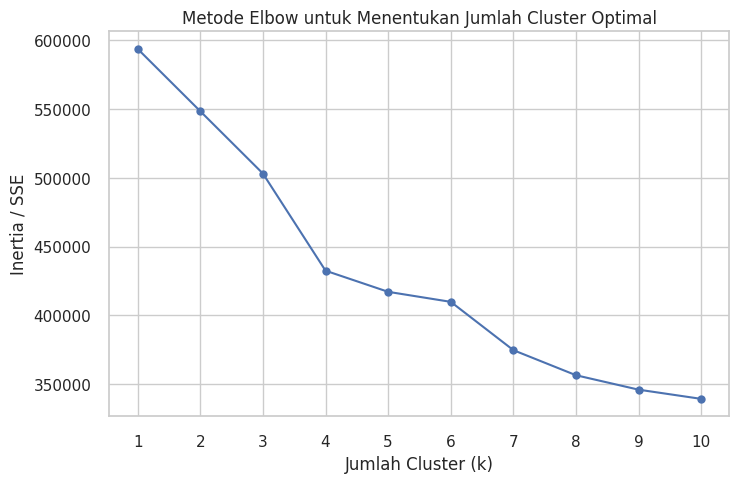

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = final_data.to_numpy()

inertia = []  # daftar untuk menyimpan nilai SSE (inertia)
K = range(1, 11)  # uji k dari 1 sampai 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot hasil Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o', linestyle='-', color='b')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia / SSE')
plt.xticks(K)
plt.grid(True)
plt.show()

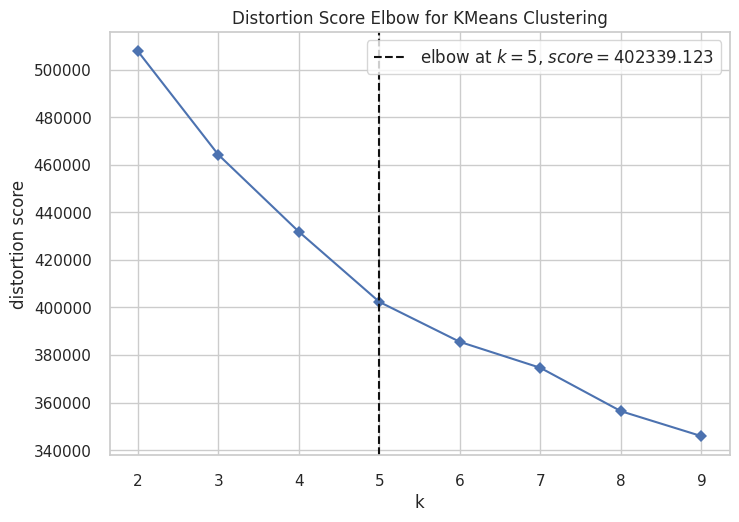

Elbow k (distortion) : 5


In [ ]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
model = KMeans(random_state=42, n_init = 10)
visualizer = KElbowVisualizer(model, k=(2, 10),
                              metric="distortion", timings=False)
visualizer.fit(final_data)
visualizer.show()
print("Elbow k (distortion) :", visualizer.elbow_value_)

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(final_data)
    score = silhouette_score(final_data, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1623
K = 3, Silhouette Score = 0.1249
K = 4, Silhouette Score = 0.1462
K = 5, Silhouette Score = 0.1569
K = 6, Silhouette Score = 0.1357
K = 7, Silhouette Score = 0.1742
K = 8, Silhouette Score = 0.1573
K = 9, Silhouette Score = 0.1610


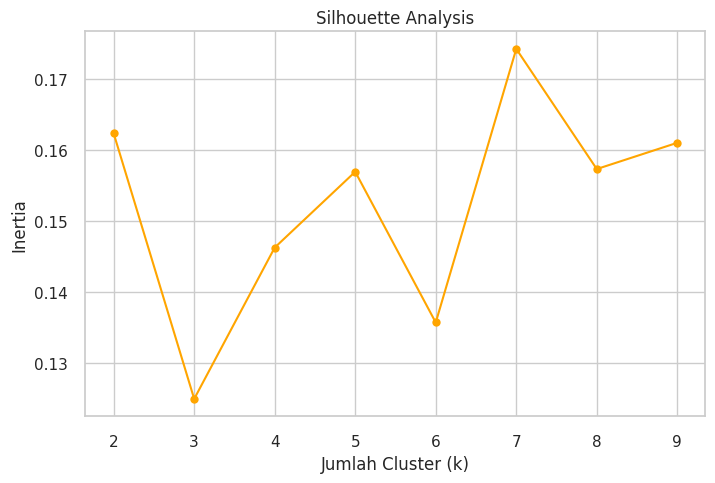

In [ ]:
K_range = range(2, 10)
silhouette_values = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(final_data)
    silhouette_values.append(silhouette_score(final_data, labels))

# Plot Silhouette
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_values, marker='o', color='orange')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Silhouette Analysis')
plt.grid(True)
plt.show()

In [ ]:
# Membuat KMeans dengan 5 cluster
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(final_data)

In [ ]:
# Tambahkan hasil cluster ke dataframe
final_data["cluster"] = labels
data["cluster"] = labels

In [ ]:
data["cluster"].value_counts()

,count
cluster,
4,54941
3,46867
0,43464
1,31439
2,17712


In [ ]:
# Menyimpan model menggunakan joblib
import joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

# **5. Interpretasi Cluster**

In [ ]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.
num_cols = final_data.select_dtypes(include=[np.number]).columns.tolist()

if 'cluster' not in final_data.columns:
    raise ValueError("Kolom 'cluster' belum tersedia. Jalankan cell KMeans terlebih dahulu.")

agg_table = final_data.groupby('cluster')[num_cols].agg(['mean','min','max'])
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(agg_table)

             UMUR                  HARI             JAM_sin            \
             mean   min   max      mean  min  max      mean  min  max   
cluster                                                                 
0        0.398560  0.01  0.96  0.292403  0.0  1.0  0.511382  0.0  1.0   
1        0.169351  0.00  0.88  0.302459  0.0  1.0  0.453982  0.0  1.0   
2        0.487636  0.00  1.00  0.279189  0.0  1.0  0.504671  0.0  1.0   
3        0.408370  0.00  1.00  0.289607  0.0  1.0  0.521113  0.0  1.0   
4        0.339449  0.00  0.99  0.280810  0.0  1.0  0.527329  0.0  1.0   

          JAM_cos           BULAN_sin           BULAN_cos            \
             mean  min  max      mean  min  max      mean  min  max   
cluster                                                               
0        0.446753  0.0  1.0  0.512622  0.0  1.0  0.477201  0.0  1.0   
1        0.456175  0.0  1.0  0.512844  0.0  1.0  0.488367  0.0  1.0   
2        0.427470  0.0  1.0  0.512513  0.0  1.0  0.487956  0

# **6. Mengeksport Data**
1.   Simpan nama kolom hasil clustering dengan nama Target.
2.   Simpan hasilnya ke dalam file CSV menggunakan function to_csv().

In [ ]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
final_data = final_data.rename(columns={'cluster' : 'Target'})
data = data.rename(columns={'cluster': 'Target'}) # Rename cluster column in the original data as well

In [ ]:
# Simpan Data
final_data.to_csv('data_clustering.csv', index=False)

from google.colab import files
files.download('data_clustering.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

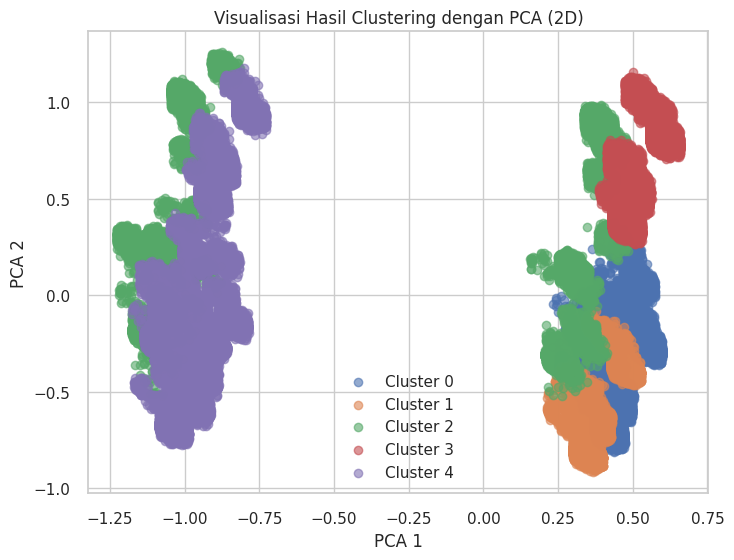

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Pastikan dataset hasil encoding (bukan yang inverse)
X = final_data.drop(columns=['Target'])
y = final_data['Target']

# Terapkan PCA ke 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Buat DataFrame hasil reduksi dimensi
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Target'] = y.values

# --- Visualisasi hasil PCA 2D ---
plt.figure(figsize=(8,6))
for t in sorted(pca_df['Target'].unique()):
    subset = pca_df[pca_df['Target'] == t]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {t}', alpha=0.6)

plt.title('Visualisasi Hasil Clustering dengan PCA (2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

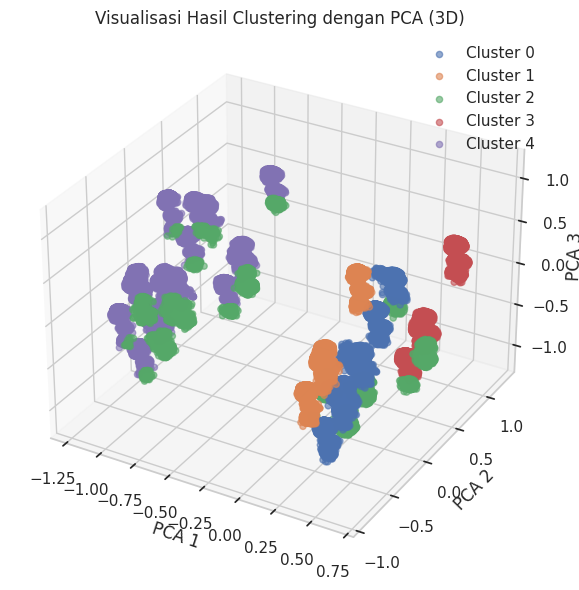

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# PCA ke 3 dimensi
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df['Target'] = y.values

# --- Visualisasi 3D ---
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

for t in sorted(pca_df['Target'].unique()):
    subset = pca_df[pca_df['Target'] == t]
    ax.scatter(subset['PCA1'], subset['PCA2'], subset['PCA3'], label=f'Cluster {t}', alpha=0.6)

ax.set_title('Visualisasi Hasil Clustering dengan PCA (3D)')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.legend()
plt.show()


In [ ]:
# Copy dataset hasil encoding
final_data_inverse = final_data.copy()

# Loop untuk tiap kolom kategorikal
for col in kategorikal_cols:
    # Ambil semua kolom hasil OneHot untuk kolom ini
    ohe_cols = [c for c in final_data.columns if c.startswith(col + '_')]

    # Kalau kolom OHE ada
    if ohe_cols:
        # Balikin ke kategori berdasarkan posisi nilai 1
        final_data_inverse[col] = final_data[ohe_cols].idxmax(axis=1).str.replace(col + '_', '')

        # Hapus kolom one-hot aslinya
        final_data_inverse.drop(columns=ohe_cols, inplace=True)

# Tampilkan hasil inverse
final_data_inverse.head()

,UMUR,HARI,JAM_sin,JAM_cos,BULAN_sin,BULAN_cos,Target,JENIS_KELAMIN,PROFESI,KASUS_KECELAKAAN,SIFAT_KECELAKAAN,KENDARAAN_KORBAN
0,0.25,0.0,0.50000,1.000000,0.75,0.933013,0,PRIA,KARYAWAN SWASTA,TABRAKAN DEPAN-SAMPING,NORMAL,MOTOR
1,0.16,0.0,0.50000,1.000000,0.75,0.933013,1,PRIA,PELAJAR MAHASISWA,TABRAKAN DEPAN-SAMPING,NORMAL,MOTOR
2,0.55,0.0,0.62941,0.982963,0.75,0.933013,0,PRIA,BURUH PETANI,TABRAKAN DEPAN-DEPAN,NORMAL,MOTOR
3,0.19,0.0,0.75000,0.933013,0.75,0.933013,1,PRIA,PELAJAR MAHASISWA,TABRAKAN DEPAN-DEPAN,NORMAL,MOTOR
4,0.19,0.0,0.75000,0.933013,0.75,0.933013,1,PRIA,PELAJAR MAHASISWA,TABRAKAN DEPAN-DEPAN,NORMAL,MOTOR


In [ ]:
# --- ANALISIS DESKRIPTIF DATA HASIL INVERSE ---
df = final_data_inverse.copy()

# Pastikan kolom Target ada dan tidak duplikat
if 'Target' not in df.columns:
    df = df.reset_index()
if isinstance(df['Target'], pd.DataFrame):
    df['Target'] = df['Target'].iloc[:, 0]
df = df.loc[:, ~pd.Index(df.columns).duplicated(keep='first')]

# Pisahkan kolom numerik dan kategorikal
num_cols_inv = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'Target']
cat_cols_inv = [c for c in df.columns if c not in num_cols_inv and c != 'Target']

# --- Agregasi numerik (mean, min, max) ---
agg_num_inv = df.groupby('Target')[num_cols_inv].agg(['mean', 'min', 'max'])
print("Agregasi numerik (inverse):")
agg_num_inv

Agregasi numerik (inverse):


UMUR                  HARI             JAM_sin            \
            mean   min   max      mean  min  max      mean  min  max   
Target                                                                 
0       0.398560  0.01  0.96  0.292403  0.0  1.0  0.511382  0.0  1.0   
1       0.169351  0.00  0.88  0.302459  0.0  1.0  0.453982  0.0  1.0   
2       0.487636  0.00  1.00  0.279189  0.0  1.0  0.504671  0.0  1.0   
3       0.408370  0.00  1.00  0.289607  0.0  1.0  0.521113  0.0  1.0   
4       0.339449  0.00  0.99  0.280810  0.0  1.0  0.527329  0.0  1.0   

         JAM_cos           BULAN_sin           BULAN_cos            
            mean  min  max      mean  min  max      mean  min  max  
Target                                                              
0       0.446753  0.0  1.0  0.512622  0.0  1.0  0.477201  0.0  1.0  
1       0.456175  0.0  1.0  0.512844  0.0  1.0  0.488367  0.0  1.0  
2       0.427470  0.0  1.0  0.512513  0.0  1.0  0.487956  0.0  1.0  
3       0.435972  0.0  1.0  0.506000  0.0  1.0  0.488711  0.0  1.0  
4       0.358072  0.0  1.0  0.507817  0.0  1.0  0.487747  0.0  1.0

In [ ]:
# --- Agregasi kategorikal (mode) ---
agg_cat_inv = df.groupby('Target')[cat_cols_inv].agg(
    lambda x: (
        x.mode().iloc[0] if not x.mode().empty
        else (x.dropna().iloc[0] if not x.dropna().empty else "Unknown")
    )
)
print("\nAgregasi kategorikal (inverse):")
agg_cat_inv


Agregasi kategorikal (inverse):


,JENIS_KELAMIN,PROFESI,KASUS_KECELAKAAN,SIFAT_KECELAKAAN,KENDARAAN_KORBAN
Target,,,,,
0,PRIA,KARYAWAN SWASTA,TABRAKAN DEPAN-DEPAN,NORMAL,MOTOR
1,PRIA,PELAJAR MAHASISWA,TABRAKAN DEPAN-DEPAN,NORMAL,MOTOR
2,PRIA,WIRASWASTA,MENABRAK PEJALAN KAKI/SEJENISNYA,NORMAL,PEJALAN KAKI
3,PRIA,WIRASWASTA,TABRAKAN DEPAN-DEPAN,NORMAL,MOTOR
4,WANITA,WIRASWASTA,TABRAKAN DEPAN-DEPAN,NORMAL,MOTOR


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 0 – Pengendara Motor Pria Dewasa (Karyawan Swasta, Kecelakaan Depan–Depan)**:

**Rata-rata (mean):**
*   UMUR ≈ 0.398 → rentang usia dewasa muda hingga paruh baya
*   HARI ≈ 0.292 → distribusi aktivitas merata di beberapa hari kerja
*   JAM_sin/JAM_cos ≈ 0.51 / 0.45 → aktivitas terjadi di jam produktif (pagi–siang)

**Kategori Dominan:**
*   JENIS_KELAMIN = Pria
*   PROFESI = Karyawan Swasta
*   KASUS_KECELAKAAN = Tabrakan Depan–Depan
*   SIFAT_KECELAKAAN = Normal
*   KENDARAAN_KORBAN = Motor

**Analisis:**
Cluster ini menggambarkan pekerja aktif yang menggunakan motor sebagai transportasi rutin. Kecelakaan umumnya terjadi pada jam berangkat atau pulang kerja, bersifat frontal ringan.

2. **Cluster 1 – Pengendara Motor Pria Muda (Pelajar/Mahasiswa, Kecelakaan Depan–Depan)**:
**Rata-rata (mean):**
*   UMUR ≈ 0.169 → usia muda (remaja akhir–awal 20-an)
*   HARI ≈ 0.302 → aktivitas acak di berbagai hari
*   JAM_sin/JAM_cos ≈ 0.45 / 0.46 → waktu acak, bukan jam kerja
*   BULAN_sin / BULAN_cos ≈ 0.51 / 0.48 → merata sepanjang tahun

**Kategori Dominan:**
*   JENIS_KELAMIN = Pria
*   PROFESI = Pelajar/Mahasiswa
*   KASUS_KECELAKAAN = Tabrakan Depan–Depan
*   SIFAT_KECELAKAAN = Normal
*   KENDARAAN_KORBAN = Motor

**Analisis:**
Cluster ini merepresentasikan kelompok usia muda dengan mobilitas tinggi, terutama pengguna motor yang sering berkegiatan di luar jam kerja. Cenderung mengalami kecelakaan frontal ringan akibat aktivitas harian tanpa pola waktu tetap. Kecelakaan umumnya terjadi karena kurangnya pengalaman dan disiplin berkendara.

3. **Cluster 2 – Pengendara Pria Dewasa (Wiraswasta, Menabrak Pejalan Kaki/Sejenisnya)**:
**Rata-rata (mean):**
*   UMUR ≈ 0.487 → dewasa penuh (sekitar usia 30-an)
*   HARI ≈ 0.29 → aktivitas cenderung stabil pada hari kerja
*   JAM_sin/JAM_cos ≈ 0.43 / 0.42 → jam produktif (siang–sore)
*   BULAN_sin / BULAN_cos ≈ 0.51 / 0.48 → merata antar bulan

**Kategori Dominan:**
*   JENIS_KELAMIN = Pria
*   PROFESI = Wiraswasta
*   KASUS_KECELAKAAN = Menabrak Pejalan Kaki/Sejenisnya
*   SIFAT_KECELAKAAN = Normal
*   KENDARAAN_KORBAN = Pejalan Kaki

**Analisis:**
Cluster ini menggambarkan pengendara motor dewasa yang sering berkegiatan di luar ruangan (wiraswasta). Risiko kecelakaan melibatkan pejalan kaki, kemungkinan akibat aktivitas padat dan lingkungan jalan sempit.

4. **Cluster 3 – Pengendara Motor Pria Dewasa (Wiraswasta, Tabrakan Depan–Depan**:
**Rata-rata (mean):**
*   UMUR ≈ 0.408 → usia dewasa (sekitar 25–35 tahun)
*   HARI ≈ 0.289 → dominan pada hari kerja
*   JAM_sin/JAM_cos ≈ 0.53 / 0.43 → kejadian sekitar jam produktif (pagi–siang)
*   BULAN_sin / BULAN_cos ≈ 0.50 / 0.48 → stabil antar bulan

**Kategori Dominan:**
*   JENIS_KELAMIN = Pria
*   PROFESI = Wiraswasta
*   KASUS_KECELAKAAN = Tabrakan Depan–Depan
*   SIFAT_KECELAKAAN = Normal
*   KENDARAAN_KORBAN = Motor

**Analisis:**
Cluster ini menunjukkan kelompok pekerja lapangan yang sering menggunakan motor untuk kegiatan usaha. Pola waktunya menunjukkan mobilitas tinggi di siang hari, dengan kecelakaan frontal ringan akibat lalu lintas padat.

5. **Cluster 4 – Pengendara Wanita Dewasa (Wiraswasta, Kecelakaan Depan–Depan**:
**Rata-rata (mean):**
*   UMUR ≈ 0.339 → usia dewasa muda
*   HARI ≈ 0.28 → kegiatan cenderung stabil pada hari kerja
*   JAM_sin / JAM_cos ≈ 0.52 / 0.35 → kejadian pada jam pagi
*   BULAN_sin / BULAN_cos ≈ 0.51 / 0.48 → relatif merata antar bulan

**Kategori Dominan:**
*   JENIS_KELAMIN = Wanita
*   PROFESI = Wiraswasta
*   KASUS_KECELAKAAN = Tabrakan Depan–Depan
*   SIFAT_KECELAKAAN = Normal
*   KENDARAAN_KORBAN = Motor

**Analisis:**
Cluster ini menggambarkan pengendara wanita dewasa yang memiliki usaha mandiri, sering berkendara di pagi hari untuk aktivitas bisnis. Kecelakaan frontal kemungkinan terjadi di perjalanan menuju lokasi usaha atau pasar.

# **SELESAI**